# Reversible Cancelable Multi-Modal Biometric Fusion
This notebook loads the real Fingerprint and Iris features, pairs them by Person ID, and performs a complete **Open Set Identification Test** for all 3 cases requested by your mentor:
1. Only Fingerprint probe available
2. Only Iris probe available
3. Both available (Score-Level Fusion)


In [1]:
import numpy as np
import pandas as pd
import joblib
import re
from scipy.spatial.distance import euclidean, cosine

np.random.seed(42)


In [2]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


### Step 1: Data Loading & Dimensionality Alignment
Fingerprints use variable-length triangles (a dataframe per image),
while Iris uses a fixed 10D vector. To concatenate them,
we aggregate Fingerprint data into a fixed 50D vector per image (combining mean and std dev of all 25 features).


In [3]:
import os
import re
import numpy as np
import joblib
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Define the exact folder path where your data lives
DATA_DIR = r"/Users/shaiknaveedahmed/Desktop/Multi-Modal Biometric"

# Load fingerprint and iris data
print("Loading data...")
fp_data = joblib.load(os.path.join(DATA_DIR, 'enhanced_fingerprint_features.pkl'))
fp_features_dict = fp_data['features']

ir_f = np.load(os.path.join(DATA_DIR, 'iris_features.npy'))
ir_l = np.load(os.path.join(DATA_DIR, 'iris_labels.npy'))

# ============================================================
# STEP 1: Collect all triangle feature vectors
# ============================================================
print("Collecting triangle feature vectors...")
all_triangle_vectors = []
for fid, df in fp_features_dict.items():
    triangle_feats = df.select_dtypes(include=[np.number]).values
    all_triangle_vectors.append(triangle_feats)

all_triangle_vectors = np.vstack(all_triangle_vectors)
print(f"Total triangles: {all_triangle_vectors.shape[0]}, original feature dim: {all_triangle_vectors.shape[1]}")

# ============================================================
# STEP 2: Normalise and cluster (high‑dimensional histogram)
# ============================================================
scaler = StandardScaler()
all_triangle_vectors_norm = scaler.fit_transform(all_triangle_vectors)

K_HIGH = 500
print(f"Clustering into {K_HIGH} clusters...")
kmeans = KMeans(n_clusters=K_HIGH, random_state=42, n_init=10)
kmeans.fit(all_triangle_vectors_norm)

# ============================================================
# STEP 3: Build high‑D histogram for each fingerprint
# ============================================================
high_dim_histograms = []   # store temporarily to fit PCA
fingerprint_ids = []       # keep track of which fingerprint each histogram belongs to
person_map = {}            # fingerprint ID -> person ID

for fid, df in fp_features_dict.items():
    match = re.search(r'_(\d+)_', fid)
    if not match:
        continue
    person_str = match.group(1).zfill(3)
    person_map[fid] = person_str
    
    triangle_feats = df.select_dtypes(include=[np.number]).values
    if triangle_feats.shape[0] == 0:
        continue
    triangle_feats_norm = scaler.transform(triangle_feats)
    labels = kmeans.predict(triangle_feats_norm)
    hist, _ = np.histogram(labels, bins=np.arange(K_HIGH+1), density=True)
    high_dim_histograms.append(hist)
    fingerprint_ids.append(fid)

high_dim_histograms = np.array(high_dim_histograms)   # shape (n_fingerprints, K_HIGH)
print(f"High‑dim histogram shape: {high_dim_histograms.shape}")

# ============================================================
# STEP 4: Reduce to exactly 50‑D using PCA
# ============================================================
pca = PCA(n_components=50, random_state=42)
fingerprint_50d = pca.fit_transform(high_dim_histograms)   # shape (n_fingerprints, 50)
print(f"Reduced to 50‑D fingerprint vectors. Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")



# ============================================================
# STEP 5: Group by person (each person may have multiple fingerprint samples)
# ============================================================
person_fp = {}
for i, fid in enumerate(fingerprint_ids):
    person = person_map[fid]
    if person not in person_fp:
        person_fp[person] = []
    person_fp[person].append(fingerprint_50d[i])

# ============================================================
# STEP 6: Aggregate Iris by Person (unchanged)
# ============================================================
person_ir = {}
for feats, label in zip(ir_f, ir_l):
    person_str = str(label).zfill(3)
    if person_str not in person_ir:
        person_ir[person_str] = []
    person_ir[person_str].append(feats)

# ============================================================
# STEP 7: Find overlapping persons and set dimensions
# ============================================================
common_persons = sorted(list(set(person_fp.keys()).intersection(set(person_ir.keys()))))
print(f"Found {len(common_persons)} overlapping persons.")

NUM_FP_FEATURES = 50   # exactly 50
NUM_IRIS_FEATURES = person_ir[common_persons[0]][0].shape[0]   # 10

print(f"Fingerprint feature length (after PCA): {NUM_FP_FEATURES}D")
print(f"Iris feature length:                    {NUM_IRIS_FEATURES}D")

Loading data...
Total triangles: 68710, original feature dim: 25
Clustering into 500 clusters...
High‑dim histogram shape: (880, 500)
Reduced to 50‑D fingerprint vectors. Explained variance ratio: 0.408
Found 108 overlapping persons.
Fingerprint feature length (after PCA): 50D
Iris feature length:                    10D


### Step 2: The Core Fusion Engine (Matrix Projection)


In [4]:
# Generate ONE fixed matrix for ALL users
FIXED_SEED = 42  # Any constant number
FIXED_SIZE = 60  # 50 + 10

rng = np.random.RandomState(FIXED_SEED)
random_matrix = rng.randn(FIXED_SIZE, FIXED_SIZE)
FIXED_MATRIX, R = np.linalg.qr(random_matrix)

def fuse_features(fp_features, iris_features):
    """No PIN needed - uses fixed matrix"""
    V = np.concatenate([fp_features, iris_features])
    return np.dot(FIXED_MATRIX, V)

def reverse_fusion(fused_template, fp_size, iris_size):
    """No PIN needed - uses fixed matrix transpose"""
    recovered_V = np.dot(FIXED_MATRIX.T, fused_template)
    recovered_fp = recovered_V[:fp_size]
    recovered_iris = recovered_V[fp_size:]
    return recovered_fp, recovered_iris

### Step 3: Database Enrollment
We will use the **1st Sample** (index 0) of every person to create their combined template. We give every user a custom PIN (e.g., Integer of their ID).


In [5]:
print("--- ENROLLMENT PHASE (WITHOUT USER TOKENS) ---")

database_templates = {}

for person in common_persons:
    # Take their first sample for enrollment
    fp_enroll = person_fp[person][0]
    ir_enroll = person_ir[person][0]
    
    # Perform Matrix Fusion using the FIXED matrix (no PIN needed)
    template = fuse_features(fp_enroll, ir_enroll)  # ✅ No PIN parameter
    
    # Save to "Database"
    database_templates[person] = template

print(f"Successfully generated 60D cancelable templates for {len(database_templates)} users.")
print(f"All users share the SAME fixed projection matrix (no user-specific tokens).")

--- ENROLLMENT PHASE (WITHOUT USER TOKENS) ---
Successfully generated 60D cancelable templates for 108 users.
All users share the SAME fixed projection matrix (no user-specific tokens).


### Step 4: Authentication & The Three Cases
Now, we act like the users are walking up to the scanner. We use **Sample 2** (index 1) as the live probe. We loop through all 108 users to test overall systemic accuracy for Case 1, Case 2, and Case 3.


In [6]:
print("\n--- AUTHENTICATION SIMULATION (WITHOUT USER TOKENS) ---\n")

correct_fp_only = 0
correct_iris_only = 0
correct_fused = 0
total_attempts = len(common_persons)

for true_person in common_persons:
    # Get live probe scans (sample index 1)
    live_fp = person_fp[true_person][1]
    live_ir = person_ir[true_person][1]
    
    best_matching_person_fp = None
    best_matching_person_ir = None
    best_matching_person_fused = None
    
    min_dist_fp = float('inf')
    min_dist_ir = float('inf')
    min_dist_fused = float('inf')

    # Compare probe against ALL people in the database
    for db_person, stored_template in database_templates.items():
        # Reverse the fusion using the FIXED matrix
        recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)
        
        # Calculate Cosine distances
        dist_fp = cosine(live_fp, recovered_fp)
        dist_ir = cosine(live_ir, recovered_ir)
        
        # Case 1: Fingerprint Only
        if dist_fp < min_dist_fp:
            min_dist_fp = dist_fp
            best_matching_person_fp = db_person
            
        # Case 2: Iris Only
        if dist_ir < min_dist_ir:
            min_dist_ir = dist_ir
            best_matching_person_ir = db_person
            
        # Case 3: Score-level fusion
        dist_fused = (0.5 * dist_fp) + (0.5 * dist_ir)
        
        if dist_fused < min_dist_fused:
            min_dist_fused = dist_fused
            best_matching_person_fused = db_person

    # Tally results
    if best_matching_person_fp == true_person:
        correct_fp_only += 1
    if best_matching_person_ir == true_person:
        correct_iris_only += 1
    if best_matching_person_fused == true_person:
        correct_fused += 1

print(f"IDENTIFICATION ACCURACY OUT OF {total_attempts} TESTS:")
print("=" * 50)
print(f"Case 1 (Fingerprint Only):   {(correct_fp_only / total_attempts) * 100:.2f}%")
print(f"Case 2 (Iris Only):          {(correct_iris_only / total_attempts) * 100:.2f}%")
print(f"Case 3 (Fingerprint + Iris): {(correct_fused / total_attempts) * 100:.2f}%")
print("=" * 50)



--- AUTHENTICATION SIMULATION (WITHOUT USER TOKENS) ---

IDENTIFICATION ACCURACY OUT OF 108 TESTS:
Case 1 (Fingerprint Only):   22.22%
Case 2 (Iris Only):          99.07%
Case 3 (Fingerprint + Iris): 83.33%


In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


### Step 5: Advanced Performance Metrics & Optimal Thresholding
While the previous test demonstrated extreme identification accuracy by finding the "closest match" in an open system, an enterprise biometric pipeline strictly evaluates all claims against a **Threshold**.

Here, we will compute 108 **Genuine Attempts** (users claiming their true identity) and thousands of **Impostor Attempts** (users claiming false identities) using our Reversible Templates. We will use these scores to generate critical biometric metrics (ROC-AUC, Equal Error Rate, and an Optimal Security Threshold).


In [8]:
from sklearn.metrics import roc_curve, auc

print("--- GENUINE VS IMPOSTOR SCORE GENERATION ---\n")

genuine_scores_fp = []
impostor_scores_fp = []

genuine_scores_ir = []
impostor_scores_ir = []

genuine_scores_fused = []
impostor_scores_fused = []

# Loop over every live person claiming identities
for claiming_person in common_persons:
    live_fp = person_fp[claiming_person][1]    
    live_ir = person_ir[claiming_person][1]
    
    # Compare against every database template
    for db_person, stored_template in database_templates.items():
        recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)

        # Calculate Cosine distances (0.0 means perfect match, 1.0 means no correlation)
        dist_fp = cosine(live_fp, recovered_fp)
        dist_ir = cosine(live_ir, recovered_ir)
        dist_fused = (0.5 * dist_fp) + (0.5 * dist_ir)
        
        # If the claiming person is the same as the database person, it's a Genuine Attempt
        if claiming_person == db_person:
            genuine_scores_fp.append(dist_fp)
            genuine_scores_ir.append(dist_ir)
            genuine_scores_fused.append(dist_fused)
        # Otherwise, they are an Impostor trying to hack someone else's account
        else:
            impostor_scores_fp.append(dist_fp)
            impostor_scores_ir.append(dist_ir)
            impostor_scores_fused.append(dist_fused)

print(f"Generated {len(genuine_scores_fused)} Genuine Scores.")
print(f"Generated {len(impostor_scores_fused)} Impostor Scores.")


--- GENUINE VS IMPOSTOR SCORE GENERATION ---

Generated 108 Genuine Scores.
Generated 11556 Impostor Scores.


### Step 6: Visualizing the Threshold and ROC-AUC


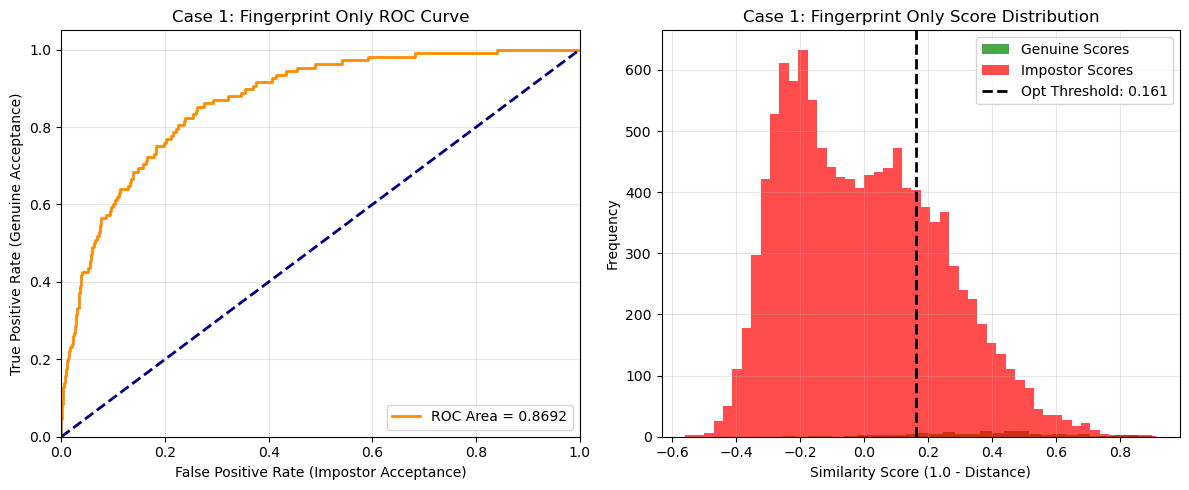

📊 CASE 1: FINGERPRINT ONLY PERFORMANCE METRICS:
  ROC-AUC Score:      0.8692
  Equal Error Rate:   21.56%
  Optimal Threshold:  Similarity > 0.1612



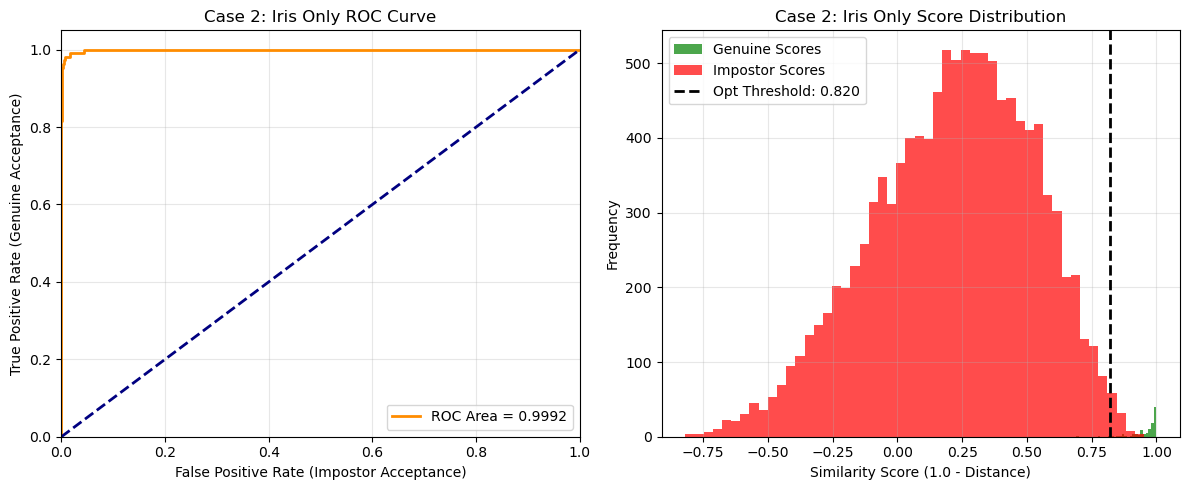

📊 CASE 2: IRIS ONLY PERFORMANCE METRICS:
  ROC-AUC Score:      0.9992
  Equal Error Rate:   1.64%
  Optimal Threshold:  Similarity > 0.8201



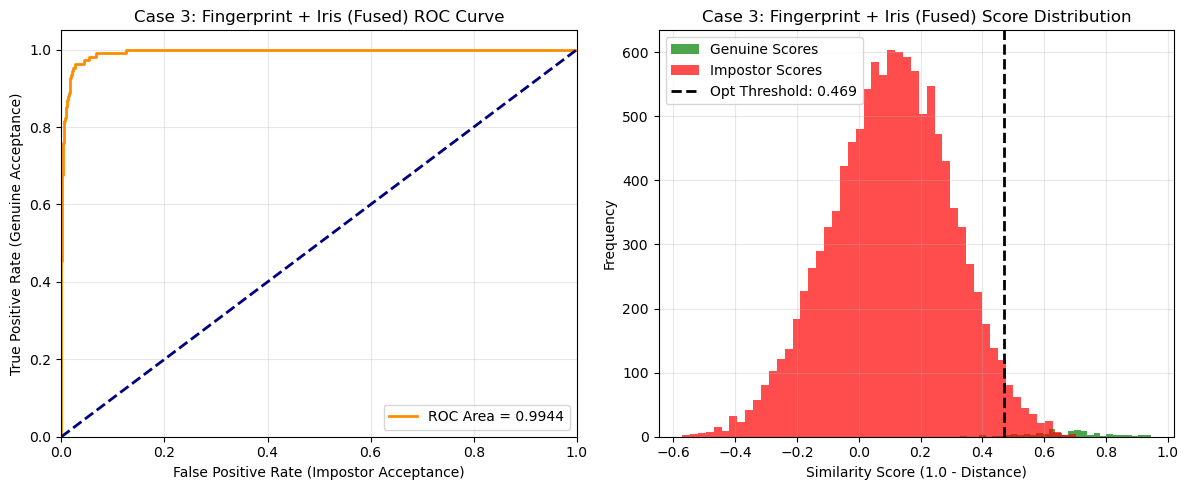

📊 CASE 3: FINGERPRINT + IRIS (FUSED) PERFORMANCE METRICS:
  ROC-AUC Score:      0.9944
  Equal Error Rate:   4.32%
  Optimal Threshold:  Similarity > 0.4693



In [9]:
import matplotlib.pyplot as plt

def evaluate_and_plot(genuine, impostor, modality_name):
    # Prepare Labels: 1 for Genuine (Match), 0 for Impostor (Non-Match)
    # Note: Because these are DISTANCES (lower is closer), we invert them so higher score = better match
    # Example: score = 1.0 - distance
    
    gen_scores = [1.0 - d for d in genuine]
    imp_scores = [1.0 - d for d in impostor]
    
    labels = np.array([1] * len(gen_scores) + [0] * len(imp_scores))
    scores = np.array(gen_scores + imp_scores)
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    # Calculate Equal Error Rate (where False Positive Rate == False Negative Rate)
    # False Negative Rate = 1 - True Positive Rate
    fnr = 1 - tpr
    eer_index = np.nanargmin(np.absolute((fnr - fpr)))
    eer = fpr[eer_index]
    
    # Calculate Optimal Threshold using Youden's J statistic
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]
    
    # --- PLOTTING ROC ---
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Area = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Impostor Acceptance)')
    plt.ylabel('True Positive Rate (Genuine Acceptance)')
    plt.title(f'{modality_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    # --- PLOTTING SCORE DISTRIBUTION ---
    plt.subplot(1, 2, 2)
    plt.hist(gen_scores, bins=30, alpha=0.7, color='green', label='Genuine Scores')
    plt.hist(imp_scores, bins=50, alpha=0.7, color='red', label='Impostor Scores')
    plt.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Opt Threshold: {optimal_threshold:.3f}')
    plt.xlabel('Similarity Score (1.0 - Distance)')
    plt.ylabel('Frequency')
    plt.title(f'{modality_name} Score Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 {modality_name.upper()} PERFORMANCE METRICS:")
    print(f"  ROC-AUC Score:      {roc_auc:.4f}")
    print(f"  Equal Error Rate:   {eer * 100:.2f}%")
    print(f"  Optimal Threshold:  Similarity > {optimal_threshold:.4f}\n")

# Run Evaluation for all three cases!
evaluate_and_plot(genuine_scores_fp, impostor_scores_fp, "Case 1: Fingerprint Only")
evaluate_and_plot(genuine_scores_ir, impostor_scores_ir, "Case 2: Iris Only")
evaluate_and_plot(genuine_scores_fused, impostor_scores_fused, "Case 3: Fingerprint + Iris (Fused)")
